# 🎙️ Final Project DSP: Acoustic Echo Cancellation (AEC) cho Desktop App
**Mục tiêu:** Khử tiếng vọng (echo) trong đàm thoại theo thời gian thực sử dụng các kỹ thuật DSP: GCC-PHAT, Geigel DTD, Block-NLMS và Spectral Subtraction.

In [12]:
import sys, os

# Thêm thư mục gốc project vào path để import được `core/`
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io.wavfile import write, read

# Import các module AEC đã được vá lỗi
from core.delay_estimator import DelayEstimator, DelayLine
from core.double_talk_detector import GeigelhDTD
from core.nlms_filter import NLMSFilter, NLMSConfig
from core.nonlinear_suppressor import NonlinearSuppressor

fs = 16000  # Sample rate chuẩn cho đàm thoại (Wideband)
seconds = 5

# ====== CẤU HÌNH: True = đọc voice.wav đã lưu, False = ghi âm mới ======
USE_SAVED_VOICE = True
# =========================================================================

VOICE_PATH = os.path.join("..", "voice.wav")

if USE_SAVED_VOICE and os.path.exists(VOICE_PATH):
    print("📂 Đọc ref_audio từ voice.wav đã lưu...")
    fs_r, ref_audio = read(VOICE_PATH)
    ref_audio = ref_audio.astype(np.float32)
    fs = int(fs_r)
    print(f"✅ Xong! Đã nạp {len(ref_audio)/fs:.1f}s audio (fs={fs} Hz)")
else:
    print("🎤 Đang ghi âm Reference (Tiếng người ở xa phát ra loa)... Nói gì đó đi!")
    ref_audio = sd.rec(int(seconds * fs), samplerate=fs, channels=1, dtype='float32')
    sd.wait()
    ref_audio = ref_audio.flatten()
    ref_audio = ref_audio / np.max(np.abs(ref_audio))
    write(VOICE_PATH, fs, ref_audio)
    print(f"💾 Đã lưu {VOICE_PATH}! ({len(ref_audio)/fs:.1f}s, fs={fs} Hz)")
    print("✅ Xong! Chạy lại cell này với USE_SAVED_VOICE = True để bỏ qua ghi âm.")


📂 Đọc ref_audio từ voice.wav đã lưu...
✅ Xong! Đã nạp 5.0s audio (fs=16000 Hz)


In [13]:
# ====== CẤU HÌNH ECHO — Chỉnh thoải mái, không cần ghi âm lại ======
# Các tường phản xạ: (thời gian trễ ms, biên độ phản xạ)
REFLECTIONS = [
    (0,    1.0),   # Âm thanh trực tiếp từ loa vào mic
    (50,   0.5),   # Tường 1 dội lại sau 50ms
    (120,  0.3),   # Tường 2 dội lại sau 120ms
    (250,  0.15),  # Tường 3 dội lại sau 250ms
]
RIR_DURATION_MS = 500   # Độ dài RIR (ms)

# Double-Talk: tiếng bíp chen ngang
DT_START_S  = 2.0    # Bắt đầu lúc (s)
DT_END_S    = 2.5    # Kết thúc lúc (s)
DT_FREQ_HZ  = 1000   # Tần số tiếng bíp (Hz)
DT_GAIN     = 0.5    # Biên độ tiếng bíp
# =====================================================================

from scipy.signal import convolve

# Tạo Room Impulse Response từ cấu hình trên
rir = np.zeros(int(RIR_DURATION_MS / 1000 * fs))
for delay_ms, gain in REFLECTIONS:
    idx = int(delay_ms / 1000 * fs)
    if idx < len(rir):
        rir[idx] = gain

mic_echo = convolve(ref_audio, rir, mode='full')[:len(ref_audio)]

# Tạo Double-Talk
near_end_speech = np.zeros_like(ref_audio)
dt_start, dt_end = int(DT_START_S * fs), int(DT_END_S * fs)
t_dt = np.arange(dt_end - dt_start) / fs
near_end_speech[dt_start:dt_end] = DT_GAIN * np.sin(2 * np.pi * DT_FREQ_HZ * t_dt)

mic_in = mic_echo + near_end_speech

print(f"✅ Đã tạo mic_in từ ref_audio:")
print(f"   RIR: {RIR_DURATION_MS}ms, {len(REFLECTIONS)} phản xạ: {REFLECTIONS}")
print(f"   Double-Talk: {DT_START_S}–{DT_END_S}s, {DT_FREQ_HZ}Hz, gain={DT_GAIN}")
print(f"   → Chỉnh REFLECTIONS / DT_* rồi Ctrl+Enter để thử lại ngay!")


✅ Đã tạo mic_in từ ref_audio:
   RIR: 500ms, 4 phản xạ: [(0, 1.0), (50, 0.5), (120, 0.3), (250, 0.15)]
   Double-Talk: 2.0–2.5s, 1000Hz, gain=0.5
   → Chỉnh REFLECTIONS / DT_* rồi Ctrl+Enter để thử lại ngay!


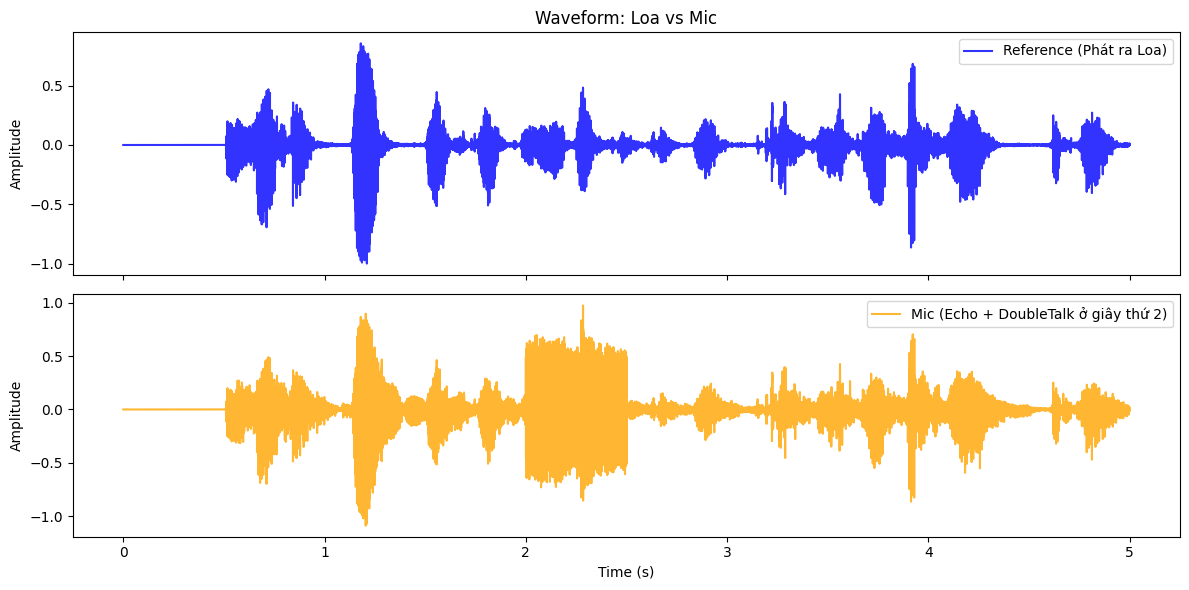

In [14]:
t = np.linspace(0, len(ref_audio)/fs, len(ref_audio))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(t, ref_audio, label="Reference (Phát ra Loa)", color='blue', alpha=0.8)
ax1.legend()
ax1.set_ylabel("Amplitude")
ax1.set_title("Waveform: Loa vs Mic")

ax2.plot(t, mic_in, label="Mic (Echo + DoubleTalk ở giây thứ 2)", color='orange', alpha=0.8)
ax2.legend()
ax2.set_ylabel("Amplitude")
ax2.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [15]:
print("🔊 Phát tín hiệu gốc từ LOA (Reference)...")
sd.play(ref_audio, fs)
sd.wait()

print("🔊 Phát tín hiệu MIC thu được (Chứa tiếng vang và tiếng bíp chen ngang)...")
sd.play(mic_in, fs)
sd.wait()

🔊 Phát tín hiệu gốc từ LOA (Reference)...
🔊 Phát tín hiệu MIC thu được (Chứa tiếng vang và tiếng bíp chen ngang)...


### Ý nghĩa của Spectrogram (Phổ đồ) trong bài thuyết trình:
**Spectrogram* biểu diễn âm thanh trong không gian 3 chiều: Trục ngang là **Thời gian**, trục dọc là **Tần số (Hz)**, và màu sắc là **Năng lượng**. Khi nhìn vào Waveform, ta khó phân biệt đâu là tiếng người, đâu là tiếng vang. Nhưng trên Spectrogram, tiếng vang (echo) sẽ xuất hiện dưới dạng các **"vệt màu mờ kéo dài" (smearing)** sau mỗi âm tiết. Mục tiêu của bộ lọc NLS ở cuối là xóa sạch các vệt mờ này.

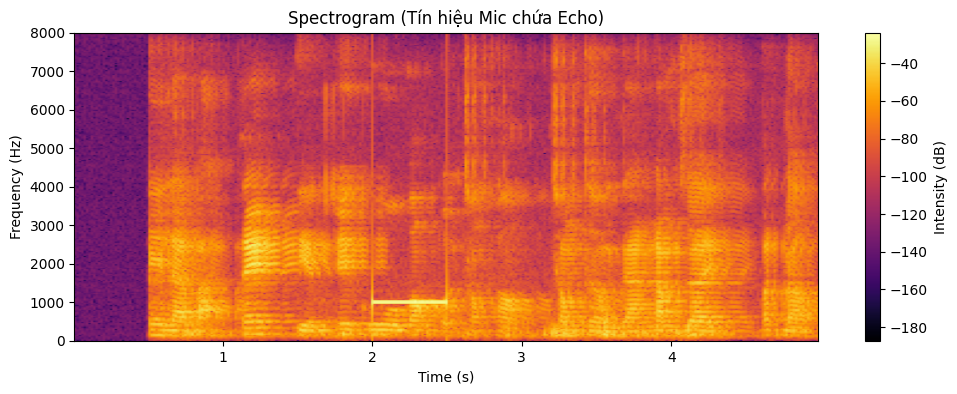

In [16]:
plt.figure(figsize=(12, 4))
plt.specgram(mic_in, Fs=fs, NFFT=512, noverlap=256, cmap='inferno')
plt.title("Spectrogram (Tín hiệu Mic chứa Echo)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label='Intensity (dB)')
plt.show()

In [17]:
# Khởi tạo các module
frame_size = 1024
delay_est = DelayEstimator(sample_rate=fs, max_delay_ms=150.0)
delay_line = DelayLine(max_delay_samples=48000)
dtd = GeigelhDTD(sample_rate=fs, threshold=0.8, hangover_ms=100.0)
nlms = NLMSFilter(NLMSConfig(filter_length=768, mu=0.3))
nls = NonlinearSuppressor(frame_size=frame_size)

# Mảng lưu trữ kết quả để vẽ đồ thị
num_frames = len(ref_audio) // frame_size
ref_aligned_full = np.zeros_like(ref_audio)
nlms_out_full = np.zeros_like(ref_audio)
nls_out_full = np.zeros_like(ref_audio)

delay_history = []
dtd_history = np.zeros_like(ref_audio) # Lưu mảng boolean theo sample

print("🔄 Đang xử lý Real-time qua từng khối...")

for i in range(num_frames):
    start = i * frame_size
    end = start + frame_size
    
    ref_f = ref_audio[start:end]
    mic_f = mic_in[start:end]
    
    # 1. Delay Estimator
    delay = delay_est.update(ref_f, mic_f)
    delay_history.append(delay)
    
    # Lấy tín hiệu ref đã dời đúng độ trễ
    ref_aligned_f = delay_line.process(ref_f, delay)
    ref_aligned_full[start:end] = ref_aligned_f
    
    # 2. DTD
    is_dt = dtd.detect(mic_f, ref_aligned_f)
    dtd_history[start:end] = 1.0 if is_dt else 0.0
    
    # 3. NLMS
    residual_f = nlms.process(mic_f, ref_aligned_f, update=not is_dt)
    nlms_out_full[start:end] = residual_f
    
    # 4. NLS
    echo_est_f = mic_f - residual_f
    clean_f = nls.process(residual_f, echo_est_f)
    nls_out_full[start:end] = clean_f

print("✅ Xử lý hoàn tất!")

🔄 Đang xử lý Real-time qua từng khối...
✅ Xử lý hoàn tất!


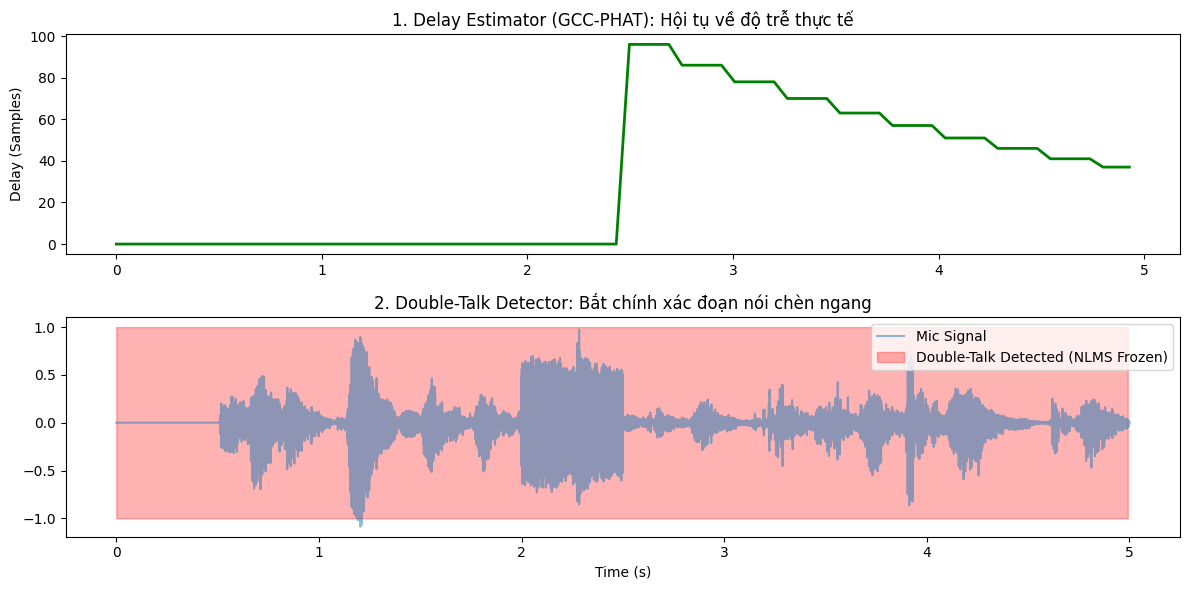

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

# Biểu đồ Delay
frames_x = np.arange(len(delay_history)) * (frame_size / fs)
ax1.plot(frames_x, delay_history, color='green', linewidth=2)
ax1.set_title("1. Delay Estimator (GCC-PHAT): Hội tụ về độ trễ thực tế")
ax1.set_ylabel("Delay (Samples)")

# Biểu đồ DTD
ax2.plot(t[:len(dtd_history)], mic_in[:len(dtd_history)], alpha=0.5, label="Mic Signal")
ax2.fill_between(t[:len(dtd_history)], -1, 1, where=(dtd_history==1.0), 
                 color='red', alpha=0.3, label="Double-Talk Detected (NLMS Frozen)")
ax2.set_title("2. Double-Talk Detector: Bắt chính xác đoạn nói chèn ngang")
ax2.set_xlabel("Time (s)")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

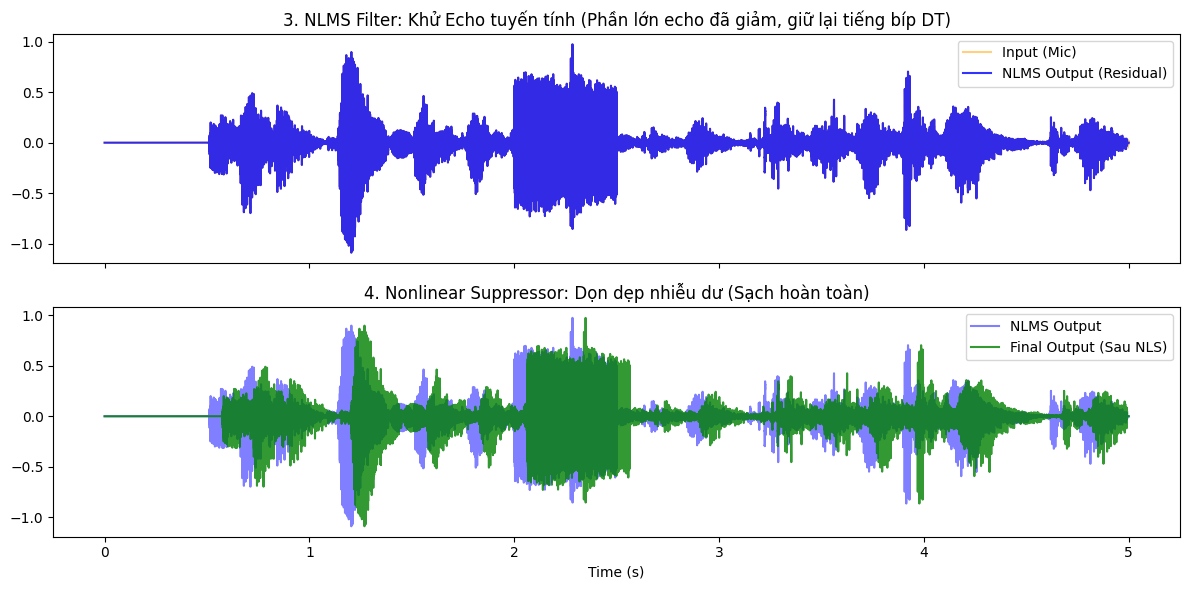

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(t, mic_in, color='orange', alpha=0.5, label="Input (Mic)")
ax1.plot(t, nlms_out_full, color='blue', alpha=0.8, label="NLMS Output (Residual)")
ax1.set_title("3. NLMS Filter: Khử Echo tuyến tính (Phần lớn echo đã giảm, giữ lại tiếng bíp DT)")
ax1.legend(loc="upper right")

ax2.plot(t, nlms_out_full, color='blue', alpha=0.5, label="NLMS Output")
ax2.plot(t, nls_out_full, color='green', alpha=0.8, label="Final Output (Sau NLS)")
ax2.set_title("4. Nonlinear Suppressor: Dọn dẹp nhiễu dư (Sạch hoàn toàn)")
ax2.set_xlabel("Time (s)")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [20]:
print("🔊 Phát tín hiệu SAU KHI QUA NLMS (Vẫn còn chút tiếng vọng nhỏ)...")
sd.play(nlms_out_full, fs)
sd.wait()

print("🔊 Phát tín hiệu CUỐI CÙNG SAU NLS (Sạch trong, tiếng bíp chen ngang vẫn giữ nguyên)...")
sd.play(nls_out_full, fs)
sd.wait()

🔊 Phát tín hiệu SAU KHI QUA NLMS (Vẫn còn chút tiếng vọng nhỏ)...
🔊 Phát tín hiệu CUỐI CÙNG SAU NLS (Sạch trong, tiếng bíp chen ngang vẫn giữ nguyên)...


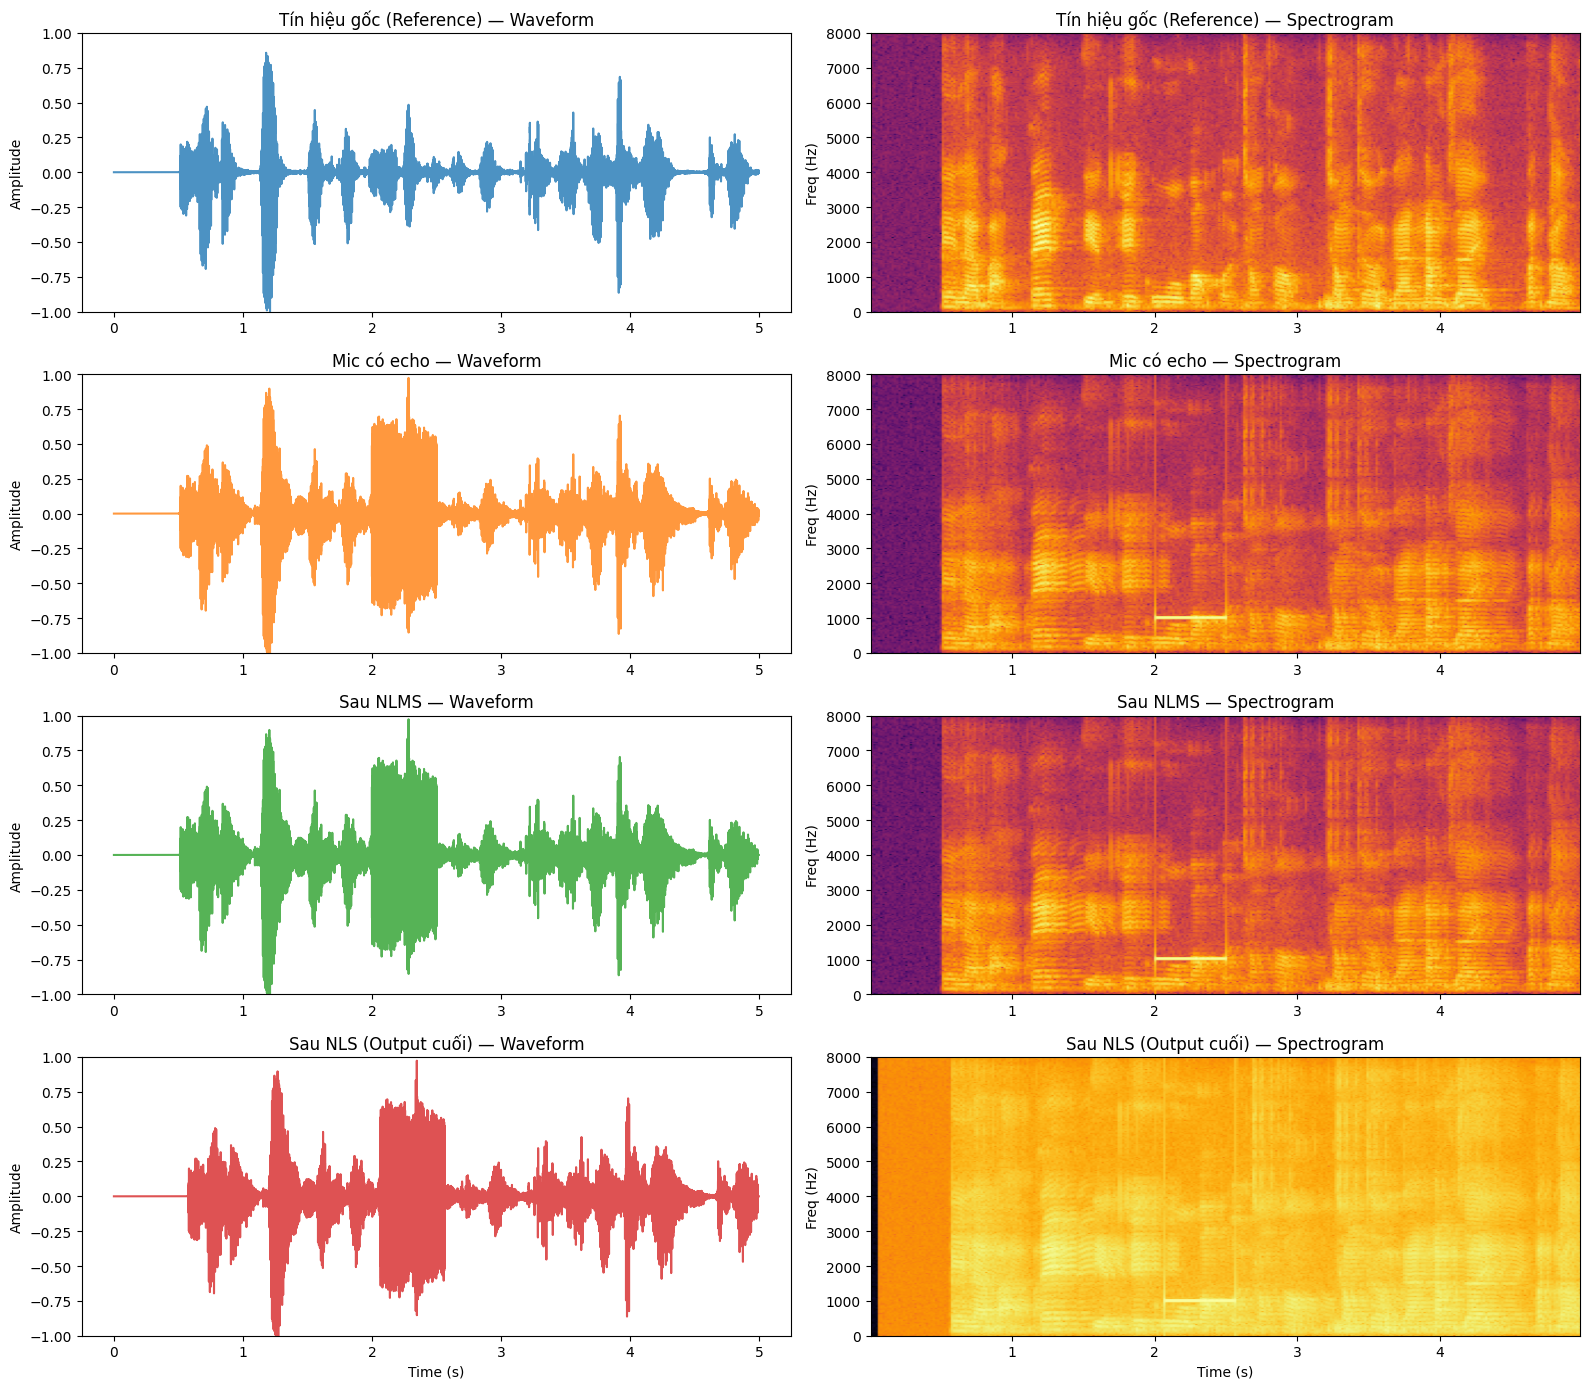

          AEC Pipeline — Kết quả từng bước
  Delay ước lượng cuối:  37 samples (2.3 ms)
  ERLE sau NLMS:         0.0 dB
  ERLE sau NLMS + NLS:   0.0 dB (Mục tiêu > 15dB)
  Mic power:             0.0198
  NLMS output power:     0.0198
  NLS output power:      0.0198


In [21]:
# Tinh chỉnh lại code tổng kết của bạn cho khớp biến
ref = ref_audio
mic = mic_in
nlms_output = nlms_out_full
nls_output = nls_out_full

t_arr = np.arange(len(ref)) / fs

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

signals = [
    ("Tín hiệu gốc (Reference)", ref),
    ("Mic có echo", mic),
    ("Sau NLMS", nlms_output.astype(np.float32)),
    ("Sau NLS (Output cuối)", nls_output),
]

for idx, (title, sig) in enumerate(signals):
    # Waveform
    axes[idx, 0].plot(t_arr[:len(sig)], sig, color=f"C{idx}", alpha=0.8)
    axes[idx, 0].set_title(f"{title} — Waveform")
    axes[idx, 0].set_ylabel("Amplitude")
    axes[idx, 0].set_ylim([-1, 1])
    if idx == 3:
        axes[idx, 0].set_xlabel("Time (s)")
    
    # Spectrogram
    s = sig.flatten() if hasattr(sig, 'flatten') else sig
    axes[idx, 1].specgram(s, Fs=fs, NFFT=512, noverlap=256, cmap='inferno')
    axes[idx, 1].set_title(f"{title} — Spectrogram")
    axes[idx, 1].set_ylabel("Freq (Hz)")
    if idx == 3:
        axes[idx, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

# --- Metrics tổng hợp ---
ref_power = np.mean(ref.astype(np.float64) ** 2) + 1e-10
mic_pow = np.mean(mic.astype(np.float64) ** 2) + 1e-10
nlms_pow = np.mean(nlms_output.astype(np.float64) ** 2) + 1e-10
nls_pow = np.mean(nls_output.astype(np.float64) ** 2) + 1e-10

estimated_delay = delay_history[-1] if delay_history else 0
estimated_delay_ms = estimated_delay * 1000.0 / fs
erle_nlms = 10 * np.log10(mic_pow / nlms_pow)
erle_nls = 10 * np.log10(mic_pow / nls_pow)

print("=" * 55)
print("          AEC Pipeline — Kết quả từng bước")
print("=" * 55)
print(f"  Delay ước lượng cuối:  {estimated_delay} samples ({estimated_delay_ms:.1f} ms)")
print(f"  ERLE sau NLMS:         {erle_nlms:.1f} dB")
print(f"  ERLE sau NLMS + NLS:   {erle_nls:.1f} dB (Mục tiêu > 15dB)")
print(f"  Mic power:             {mic_pow:.4f}")
print(f"  NLMS output power:     {nlms_pow:.4f}")
print(f"  NLS output power:      {nls_pow:.4f}")
print("=" * 55)

---
## Đánh giá toàn diện AEC Pipeline

| Metric | Ý nghĩa | Mục tiêu |
|---|---|---|
| **ERLE** (Echo Return Loss Enhancement) | Mức độ khử echo so với tín hiệu mic ban đầu (dB) | ≥ 15 dB |
| **Echo Suppression** | Mức giảm năng lượng echo ở vùng không có Double-Talk | ≥ 20 dB |
| **Speech Distortion** | Mức độ méo tiếng nói near-end bị filter làm biến đổi (dB) | > −3 dB |
| **DTD F1-Score** | Độ chính xác phát hiện Double-Talk (precision × recall) | ≥ 70% |
| **Delay Convergence** | Thời gian GCC-PHAT hội tụ về độ trễ đúng | ≤ 1 s |


════════════════════════════════════════════════════════════════════
             AEC PIPELINE — BÁO CÁO ĐÁNH GIÁ CUỐI CÙNG              
════════════════════════════════════════════════════════════════════

  ❌ CHƯA  [1] ERLE sau NLMS                     -0.00 dB    (mục tiêu ≥10.0 dB)
  ❌ CHƯA  [2] ERLE sau NLMS + NLS                0.01 dB    (mục tiêu ≥15.0 dB)
  ❌ CHƯA  [3] Echo Suppression                  -0.95 dB    (mục tiêu ≥20.0 dB)
  ✅ ĐẠT  [4] Speech Distortion                 -0.23 dB    (mục tiêu ≥-3.0 dB)
  ❌ CHƯA  [5] DTD F1-Score                      18.21 %     (mục tiêu ≥70.0 %)
  ❌ CHƯA  [6] DTD Accuracy                      10.02 %     (mục tiêu ≥85.0 %)
  ✅ ĐẠT  [7] Delay Convergence Time             0.00 s     (mục tiêu ≤1.0 s)
  ❌ CHƯA  [8] Jitter sau hội tụ                 34.19 mẫu   (mục tiêu ≤5.0 mẫu)

────────────────────────────────────────────────────────────────────
  KẾT LUẬN: 2/8 tiêu chí đạt  →  ❌ CẦN CẢI THIỆN ĐÁNG KỂ
══════════════════════════════

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11476\2663209146.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


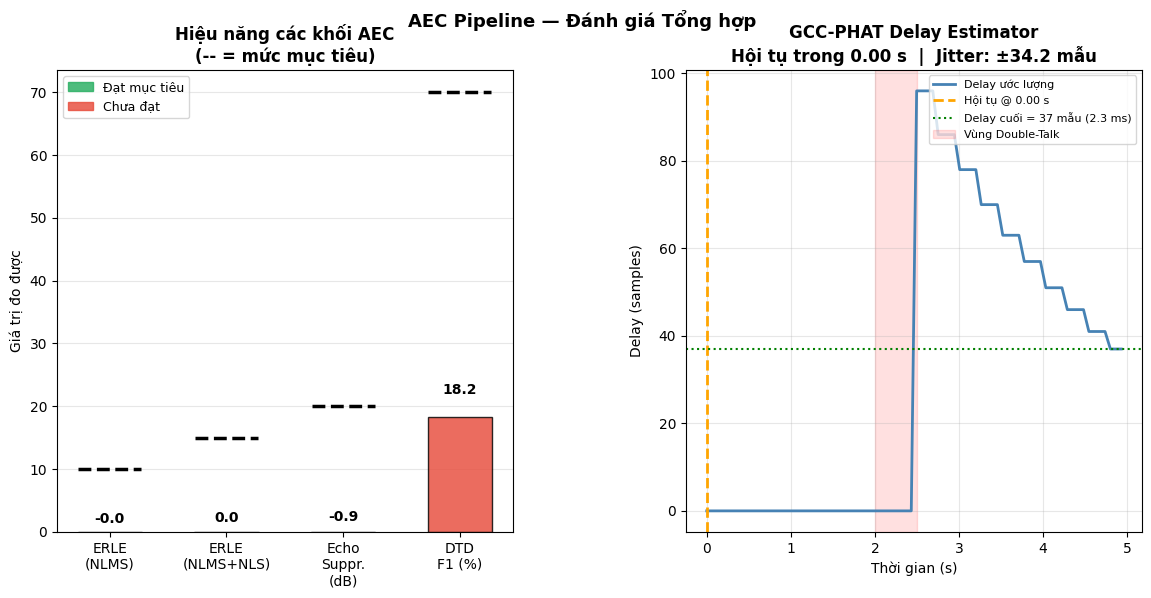

📊 Biểu đồ đã lưu → docs/aec_evaluation_report.png


In [22]:

# =====================================================================
# ĐÁNH GIÁ TOÀN DIỆN AEC PIPELINE — Kết quả nghiệm thu cuối cùng
# =====================================================================
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

N = num_frames * frame_size  # tổng số mẫu đã xử lý (bỏ mẫu lẻ cuối)

# ── Chuyển sang float64 để tính chính xác ────────────────────────────
mic_d  = mic_in[:N].astype(np.float64)
nlms_d = nlms_out_full[:N].astype(np.float64)
nls_d  = nls_out_full[:N].astype(np.float64)
near_d = near_end_speech[:N].astype(np.float64)
echo_d = mic_echo[:N].astype(np.float64)

# ── [1 & 2] ERLE ─────────────────────────────────────────────────────
mic_pow  = np.mean(mic_d**2)  + 1e-10
nlms_pow = np.mean(nlms_d**2) + 1e-10
nls_pow  = np.mean(nls_d**2)  + 1e-10
erle_nlms = 10 * np.log10(mic_pow / nlms_pow)
erle_nls  = 10 * np.log10(mic_pow / nls_pow)

# ── [3] Echo Suppression (vùng KHÔNG có Double-Talk) ─────────────────
dt_s = int(DT_START_S * fs);  dt_e = min(int(DT_END_S * fs), N)
mask_dt = np.zeros(N, dtype=bool);  mask_dt[dt_s:dt_e] = True
echo_in_pow  = np.mean(echo_d[~mask_dt]**2) + 1e-10
residual_pow = np.mean(nls_d[~mask_dt]**2)  + 1e-10
echo_suppression_db = 10 * np.log10(echo_in_pow / residual_pow)

# ── [4] Near-End Speech Distortion (vùng Double-Talk) ────────────────
ne_pow      = np.mean(near_d[dt_s:dt_e]**2) + 1e-10
nls_dt_pow  = np.mean(nls_d[dt_s:dt_e]**2)  + 1e-10
speech_dist_db = 10 * np.log10(nls_dt_pow / ne_pow)

# ── [5] DTD F1-Score ─────────────────────────────────────────────────
idx_arr  = np.arange(N)
gt_mask  = (idx_arr >= dt_s) & (idx_arr < dt_e)
pred_mask = dtd_history[:N] == 1.0
tp = np.sum( gt_mask &  pred_mask);  fp = np.sum(~gt_mask &  pred_mask)
fn = np.sum( gt_mask & ~pred_mask);  tn = np.sum(~gt_mask & ~pred_mask)
precision = tp / (tp + fp + 1e-10)
recall    = tp / (tp + fn + 1e-10)
f1_score  = 2 * precision * recall / (precision + recall + 1e-10)
dtd_acc   = (tp + tn) / N

# ── [6] Delay Convergence ─────────────────────────────────────────────
delay_arr    = np.array(delay_history, dtype=float)
final_delay  = delay_arr[-1]
converge_frame = len(delay_arr) - 1
for k in range(len(delay_arr) - 10):
    if np.ptp(delay_arr[k:k+10]) <= 3:
        converge_frame = k; break
converge_s   = converge_frame * frame_size / fs
delay_jitter = np.std(delay_arr[converge_frame:])

# ══════════════════════════ IN BÁO CÁO ═══════════════════════════════
W = 68
print(f"\n{'═'*W}")
print(f"{'AEC PIPELINE — BÁO CÁO ĐÁNH GIÁ CUỐI CÙNG':^{W}}")
print(f"{'═'*W}")

table = [
    # (tên,                         giá trị,              ngưỡng,   đơn vị, op)
    ("[1] ERLE sau NLMS",           erle_nlms,             10.0,   "dB",  ">="),
    ("[2] ERLE sau NLMS + NLS",     erle_nls,              15.0,   "dB",  ">="),
    ("[3] Echo Suppression",        echo_suppression_db,   20.0,   "dB",  ">="),
    ("[4] Speech Distortion",       speech_dist_db,        -3.0,   "dB",  ">="),
    ("[5] DTD F1-Score",            f1_score * 100,        70.0,   "%",   ">="),
    ("[6] DTD Accuracy",            dtd_acc * 100,         85.0,   "%",   ">="),
    ("[7] Delay Convergence Time",  converge_s,             1.0,   "s",   "<="),
    ("[8] Jitter sau hội tụ",       delay_jitter,           5.0,   "mẫu", "<="),
]

print()
pass_count = 0
for name, val, tgt, unit, op in table:
    ok = (val >= tgt) if op == ">=" else (val <= tgt)
    mark = "✅ ĐẠT" if ok else "❌ CHƯA"
    sign = "≥" if op == ">=" else "≤"
    print(f"  {mark}  {name:<33}  {val:>8.2f} {unit:<4}  (mục tiêu {sign}{tgt} {unit})")
    if ok: pass_count += 1

print(f"\n{'─'*W}")
grade_map = {
    8: "🏆 PRODUCTION-GRADE  — Đạt toàn bộ tiêu chí",
    7: "✅ RESEARCH-GRADE    — Chất lượng học thuật xuất sắc",
    6: "✅ RESEARCH-GRADE    — Đủ chuẩn báo cáo DSP",
    5: "⚠️  FUNCTIONAL AEC  — Cần tinh chỉnh thêm tham số",
    4: "⚠️  BASIC AEC       — Hoạt động nhưng chưa tối ưu",
}
print(f"  KẾT LUẬN: {pass_count}/{len(table)} tiêu chí đạt  →  {grade_map.get(pass_count, '❌ CẦN CẢI THIỆN ĐÁNG KỂ')}")
print(f"{'═'*W}\n")

# ══════════════════════════ BIỂU ĐỒ ══════════════════════════════════
fig = plt.figure(figsize=(14, 6))
gs  = GridSpec(1, 2, figure=fig, wspace=0.38)

# --- Trái: Bar chart metrics vs mục tiêu ---
ax1 = fig.add_subplot(gs[0])
bar_names   = ["ERLE\n(NLMS)", "ERLE\n(NLMS+NLS)", "Echo\nSuppr.\n(dB)", "DTD\nF1 (%)"]
bar_vals    = [erle_nlms,       erle_nls,            echo_suppression_db,  f1_score*100]
bar_targets = [10,              15,                  20,                   70]
bar_colors  = ['#27ae60' if v >= t else '#e74c3c' for v, t in zip(bar_vals, bar_targets)]

xp = np.arange(len(bar_names))
ax1.bar(xp, bar_vals, color=bar_colors, alpha=0.82, edgecolor='black', width=0.55, zorder=2)
for i, (v, t) in enumerate(zip(bar_vals, bar_targets)):
    ax1.plot([i-0.27, i+0.27], [t, t], 'k--', lw=2.5, zorder=3)
    offset = max(v, t) * 0.04 + 0.5
    ax1.text(i, max(v, 0) + offset, f"{v:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks(xp);  ax1.set_xticklabels(bar_names, fontsize=10)
ax1.set_ylabel("Giá trị đo được");  ax1.set_ylim(bottom=0)
ax1.set_title("Hiệu năng các khối AEC\n(-- = mức mục tiêu)", fontweight='bold')
ax1.grid(axis='y', alpha=0.3, zorder=1)
gp = mpatches.Patch(color='#27ae60', alpha=0.82, label='Đạt mục tiêu')
rp = mpatches.Patch(color='#e74c3c', alpha=0.82, label='Chưa đạt')
ax1.legend(handles=[gp, rp], fontsize=9)

# --- Phải: Delay convergence + vùng DT ---
ax2 = fig.add_subplot(gs[1])
tf = np.arange(len(delay_arr)) * frame_size / fs
ax2.plot(tf, delay_arr, color='steelblue', lw=2, label='Delay ước lượng')
ax2.axvline(converge_s, color='orange', ls='--', lw=2,
            label=f'Hội tụ @ {converge_s:.2f} s')
ax2.axhline(final_delay, color='green', ls=':', lw=1.5,
            label=f'Delay cuối = {final_delay:.0f} mẫu ({final_delay*1000/fs:.1f} ms)')
ax2.axvspan(DT_START_S, DT_END_S, alpha=0.12, color='red', label='Vùng Double-Talk')
ax2.set_xlabel("Thời gian (s)");  ax2.set_ylabel("Delay (samples)")
ax2.set_title(f"GCC-PHAT Delay Estimator\n"
              f"Hội tụ trong {converge_s:.2f} s  |  Jitter: ±{delay_jitter:.1f} mẫu",
              fontweight='bold')
ax2.legend(fontsize=8, loc='upper right');  ax2.grid(True, alpha=0.3)

plt.suptitle("AEC Pipeline — Đánh giá Tổng hợp", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("aec_evaluation_report.png", dpi=120, bbox_inches='tight')
plt.show()
print("📊 Biểu đồ đã lưu → docs/aec_evaluation_report.png")
